In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


In [2]:
sample=pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv")
df=pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv")
test=pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv")

# DATATYPES

In [3]:

print(df.dtypes)

id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


 # DESCRIPTIVE STATISTICS 
 OF COLUMNS

In [5]:
df.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


# mode

In [6]:
df.select_dtypes(include='number').mode().iloc[0]

id            0.0
feature_1    19.0
feature_2     1.0
feature_3     2.0
sentiment     2.0
Name: 0, dtype: float64

# median

In [7]:
df.select_dtypes(include='number').median()

id           3499.5
feature_1      18.0
feature_2       1.0
feature_3       3.0
sentiment       1.0
dtype: float64

# Missing values

In [8]:

print(df.isnull().sum())

# Fill numerical with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


print(df.isnull().sum())


id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64
id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64


/tmp/ipykernel_16/528377874.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_16/528377874.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [9]:
for col in test.select_dtypes(include=np.number).columns:
    test[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
for col in test.select_dtypes(include='object').columns:
    test[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_16/3571895720.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_16/3571895720.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

# Duplicate

In [10]:
df.duplicated().sum()

np.int64(0)

since there were no duplicates no rows were removed.

# Outliers

In [11]:
# Using IQR method
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Capping outliers instead of removing
    outliers=df[(df[col] > upper) |(df[col] < lower)]

    print(f"{col} :{len(outliers)}")

id :0
feature_1 :122
feature_2 :842
feature_3 :331
sentiment :0


# Visualizations

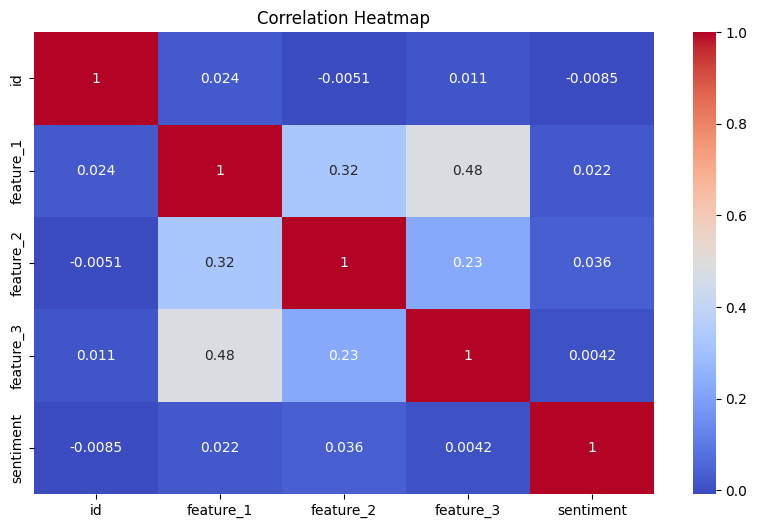

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

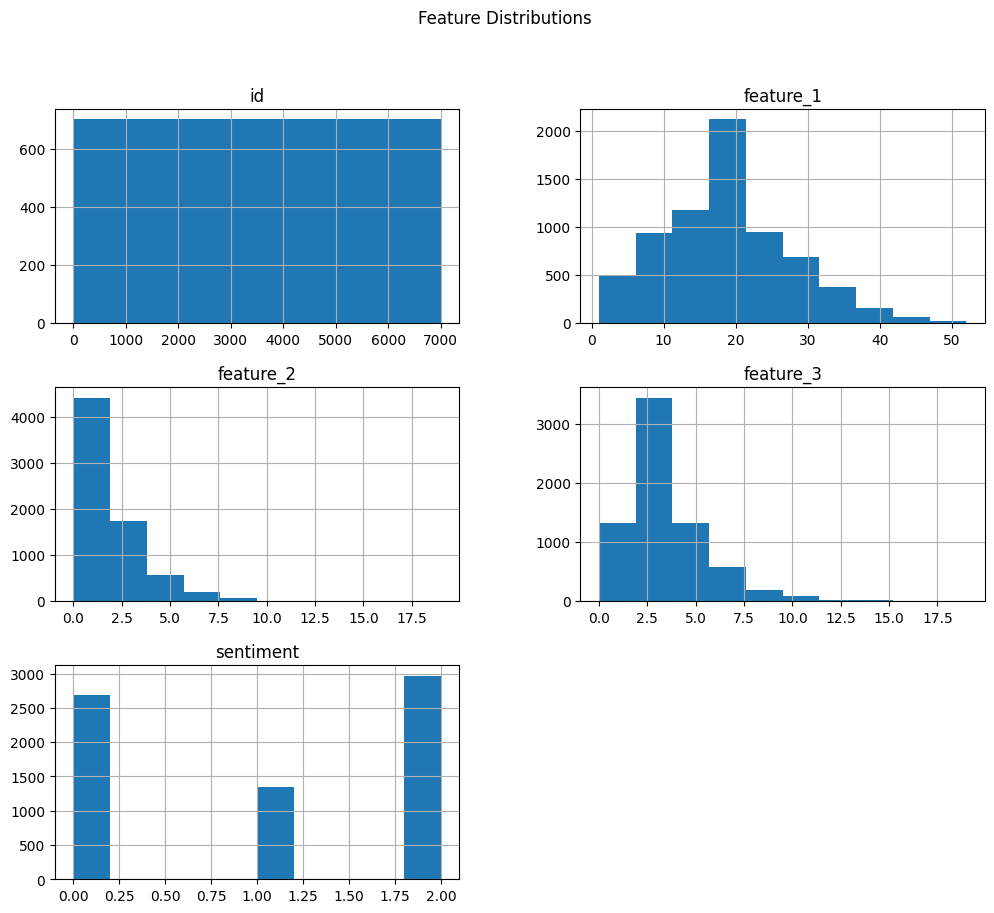

In [13]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

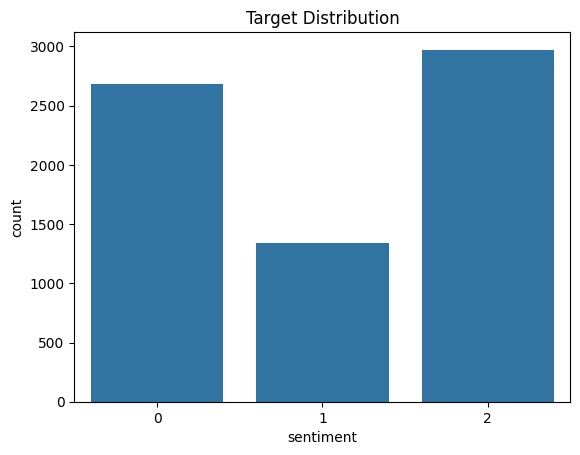

In [14]:
target = df.columns[-1]  # assuming last column is target

sns.countplot(x=df[target])
plt.title("Target Distribution")
plt.show()

the dataset is not fairly balanced

# SCALING and ENCODING

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
train_text = tfidf.fit_transform(df['phrase'])

In [16]:

test_text = tfidf.transform(test['phrase'])

In [17]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
numeric_cols = ['feature_1', 'feature_2', 'feature_3']
train_numeric = imputer.fit_transform(df[numeric_cols])

In [18]:
test_numeric=imputer.transform(test[numeric_cols])

In [19]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from scipy.sparse import hstack


X = hstack([train_text, train_numeric])
y = df['sentiment']


scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

In [20]:
test_X=hstack([test_text,test_numeric])


In [21]:
test_scaled=scaler.transform(test_X)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [24]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Adaboost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "MNB": MultinomialNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.5314
Decision Tree: 0.4886
Random Forest: 0.5486
Adaboost: 0.4300
KNN: 0.2650
MNB: 0.5200
Gradient Boosting: 0.5071


# Comparison of models

In [25]:
base_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])


base_df = base_df.sort_values(by='Accuracy', ascending=False)

print("Base Model Performance:")
print(base_df)

Base Model Performance:
                 Model  Accuracy
2        Random Forest  0.548571
0  Logistic Regression  0.531429
5                  MNB  0.520000
6    Gradient Boosting  0.507143
1        Decision Tree  0.488571
3             Adaboost  0.430000
4                  KNN  0.265000


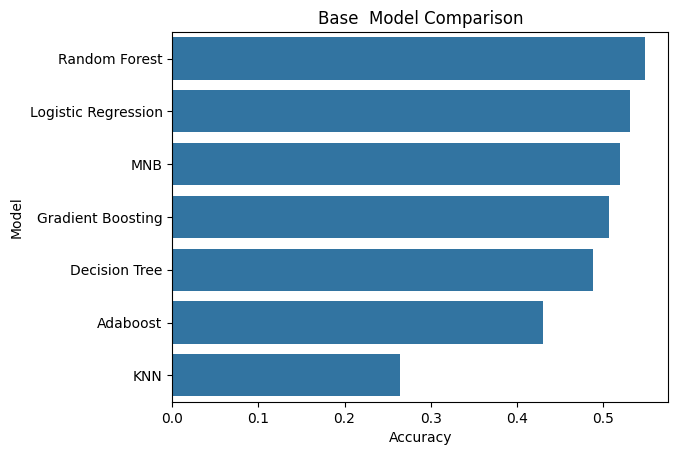

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x='Accuracy', y='Model', data=base_df)
plt.title("Base  Model Comparison")
plt.show()

# Hyperparameter tuning

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    lr_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Params:", lr_grid.best_params_)
print("Best Logistic Score:", lr_grid.best_score_)

Best Logistic Params: {'C': 0.01, 'max_iter': 500, 'solver': 'liblinear'}
Best Logistic Score: 0.5483939765005216


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Score: 0.5376770110528035


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

# 1. Define the model
nb = MultinomialNB()

# 2. Define the parameter grid
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

# 3. Setup Grid Search
# Use 'f1_macro' since your classes are imbalanced (2000/1000/1000)
grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Fit the grid search
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best accuracy Score: {grid_search.best_score_}")

Best Parameters: {'alpha': 0.1, 'fit_prior': False}
Best accuracy Score: 0.5255357142857143


In [30]:
tuned_results = {
    "Logistic Regression (Tuned)": accuracy_score(y_test, lr_grid.best_estimator_.predict(X_test)),
    "Random Forest (Tuned)": accuracy_score(y_test, rf_grid.best_estimator_.predict(X_test)),
    "MultinomialNB (Tuned)": accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
}

tuned_df = pd.DataFrame(list(tuned_results.items()), columns=['Model', 'Accuracy'])

tuned_df = tuned_df.sort_values(by='Accuracy', ascending=False)

print("Tuned Model Performance:")
print(tuned_df)

Tuned Model Performance:
                         Model  Accuracy
1        Random Forest (Tuned)  0.547143
0  Logistic Regression (Tuned)  0.544286
2        MultinomialNB (Tuned)  0.517857


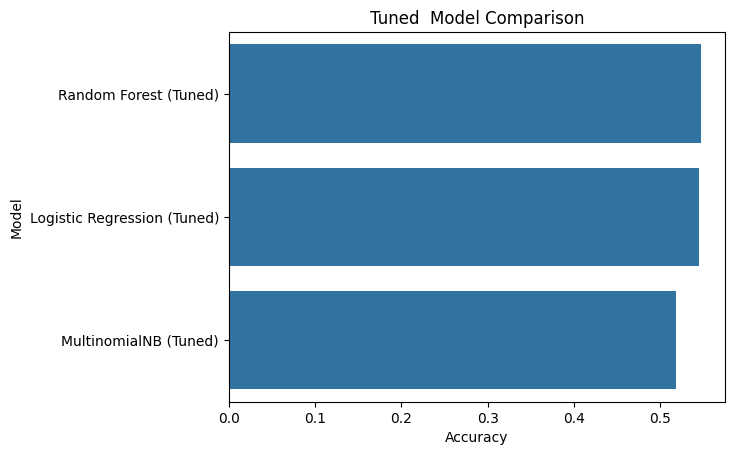

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x='Accuracy', y='Model', data=tuned_df)
plt.title("Tuned  Model Comparison")
plt.show()

In [32]:
preds = rf_grid.predict(test_scaled)

In [33]:
submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': preds
})

submission.to_csv("submission.csv", index=False)

In [34]:
submission.head()

,id,sentiment
0,0,0
1,1,2
2,2,0
3,3,2
4,4,0
